In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras import mixed_precision

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42

# Giảm kích thước ảnh và batch để tránh OOM
IMG_SIZE = 224
BATCH_SIZE = 1

# Không dùng AUTOTUNE quá mạnh để tránh ngốn RAM
AUTOTUNE = 1

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Không bật được memory growth:", e)

# Giảm VRAM khi train trên GPU
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", mixed_precision.global_policy())

2026-04-17 16:56:52.381749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776445012.600590      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776445012.666030      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776445013.198965      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776445013.199001      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776445013.199004      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [2]:
dataset1_dirs = glob.glob("/kaggle/input/**/9CTscans_tiff/Dataset1/tr_im", recursive=True)
dataset3_root = glob.glob("/kaggle/input/**/9CTscans_tiff/Dataset3", recursive=True)

if len(dataset1_dirs) == 0:
    raise FileNotFoundError("Không tìm thấy thư mục Dataset1/tr_im trong /kaggle/input")

if len(dataset3_root) == 0:
    raise FileNotFoundError("Không tìm thấy thư mục Dataset3 trong /kaggle/input")

DATASET1_DIR = dataset1_dirs[0]
DATASET3_DIR = dataset3_root[0]

print("DATASET1_DIR =", DATASET1_DIR)
print("DATASET3_DIR =", DATASET3_DIR)

DATASET1_DIR = /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset1/tr_im
DATASET3_DIR = /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3


In [3]:
dataset3_subdirs = sorted(
    list(set(os.path.dirname(p) for p in glob.glob(os.path.join(DATASET3_DIR, "**", "*.tif"), recursive=True)))
)

print("Các thư mục con trong Dataset3 có chứa TIFF:")
for d in dataset3_subdirs:
    print("-", d)

Các thư mục con trong Dataset3 có chứa TIFF:
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_001
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_002
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_003
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_004
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_005
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_006
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_007
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_008
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_009
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTscans_tiff/Dataset3/coronacases_010
- /kaggle/input/datasets/thanhbn/pneumonia-dataset/9CTs

In [4]:
def collect_triplets_from_dir(data_dir):
    triplets = []
    all_tifs = sorted(glob.glob(os.path.join(data_dir, "*.tif")))

    for img_path in all_tifs:
        name = os.path.basename(img_path)

        if name.endswith("_lung_mask.tif") or name.endswith("_mask.tif"):
            continue

        base = name[:-4]
        lung_path = os.path.join(data_dir, base + "_lung_mask.tif")
        lesion_path = os.path.join(data_dir, base + "_mask.tif")

        if os.path.exists(lung_path) and os.path.exists(lesion_path):
            triplets.append((img_path, lung_path, lesion_path, base))

    return triplets


def collect_triplets_from_many_dirs(dir_list):
    all_triplets = []
    for d in dir_list:
        all_triplets.extend(collect_triplets_from_dir(d))
    return all_triplets

In [5]:
# Dataset1 chỉ dùng để test
test_triplets = collect_triplets_from_dir(DATASET1_DIR)

# Dataset3 dùng để train/val
dataset3_triplets = collect_triplets_from_many_dirs(dataset3_subdirs)

print("Số mẫu Dataset3:", len(dataset3_triplets))
print("Số mẫu Dataset1:", len(test_triplets))


def extract_patient_id(triplet):
    """
    Cố gắng suy ra ID ca bệnh để chia train/val theo bệnh nhân thay vì theo lát cắt.
    Ưu tiên:
    1) tên thư mục cha
    2) sid bỏ số lát cắt ở cuối
    3) fallback: sid đầy đủ
    """
    img_path, lung_path, lesion_path, sid = triplet

    parent_dir = os.path.basename(os.path.dirname(img_path))
    if parent_dir and parent_dir.lower() not in {"dataset3", "tr_im", "images", "image", "img"}:
        return parent_dir

    # bỏ hậu tố số lát cắt ở cuối, ví dụ patientA_0007 -> patientA
    pid = re.sub(r'([_-]?\d+)$', '', sid)
    pid = pid.rstrip('_-')
    return pid if pid else sid


def split_train_val_by_patient(triplets, train_ratio=0.9, seed=SEED):
    grouped = {}
    for t in triplets:
        pid = extract_patient_id(t)
        grouped.setdefault(pid, []).append(t)

    patient_ids = sorted(grouped.keys())
    rng = random.Random(seed)
    rng.shuffle(patient_ids)

    n_train_patients = max(1, int(round(train_ratio * len(patient_ids))))
    if len(patient_ids) > 1:
        n_train_patients = min(n_train_patients, len(patient_ids) - 1)

    train_patient_ids = set(patient_ids[:n_train_patients])
    val_patient_ids = set(patient_ids[n_train_patients:])

    train_triplets = []
    val_triplets = []

    for pid, samples in grouped.items():
        if pid in train_patient_ids:
            train_triplets.extend(samples)
        else:
            val_triplets.extend(samples)

    rng.shuffle(train_triplets)
    rng.shuffle(val_triplets)

    return train_triplets, val_triplets, patient_ids, train_patient_ids, val_patient_ids


train_triplets, val_triplets, all_patient_ids, train_patient_ids, val_patient_ids = split_train_val_by_patient(
    dataset3_triplets,
    train_ratio=0.9,
    seed=SEED
)

print("Tổng số ca bệnh Dataset3:", len(all_patient_ids))
print("Số ca train:", len(train_patient_ids))
print("Số ca val  :", len(val_patient_ids))
print("Train samples (from Dataset3):", len(train_triplets))
print("Val samples   (from Dataset3):", len(val_triplets))
print("Test samples  (from Dataset1):", len(test_triplets))
print("Train/Val giao nhau theo bệnh nhân:", len(train_patient_ids.intersection(val_patient_ids)))

Số mẫu Dataset3: 3520
Số mẫu Dataset1: 100
Tổng số ca bệnh Dataset3: 20
Số ca train: 18
Số ca val  : 2
Train samples (from Dataset3): 2949
Val samples   (from Dataset3): 571
Test samples  (from Dataset1): 100
Train/Val giao nhau theo bệnh nhân: 0


In [6]:
def _read_tif_cv2(path):
    # chuyển mọi kiểu input về str Python
    if isinstance(path, tf.Tensor):
        path = path.numpy()

    if isinstance(path, np.ndarray):
        path = path.item()

    if isinstance(path, bytes):
        path = path.decode("utf-8")

    path = str(path)

    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Không đọc được ảnh: {path}")

    img = img.astype(np.float32)

    if img.ndim == 3:
        if img.shape[-1] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            img = img[..., 0]

    return img[..., np.newaxis]   # (H, W, 1)


def read_tif_tf(path):
    img = tf.numpy_function(_read_tif_cv2, [path], tf.float32)
    img.set_shape([None, None, 1])
    return img

In [7]:
USE_LUNG_CROP = True
USE_LUNG_MASKING = True
USE_IMAGENET_INPUT_RANGE = True   # True nếu dùng EfficientNet pretrained ImageNet

def crop_to_lung_region(img, lung, lesion, margin=10):
    lung_bin = tf.cast(lung > 127.0, tf.float32)
    coords = tf.cast(tf.where(lung_bin[..., 0] > 0), tf.int32)

    def do_crop():
        y_min = tf.maximum(tf.reduce_min(coords[:, 0]) - margin, 0)
        y_max = tf.minimum(tf.reduce_max(coords[:, 0]) + margin + 1, tf.shape(img)[0])
        x_min = tf.maximum(tf.reduce_min(coords[:, 1]) - margin, 0)
        x_max = tf.minimum(tf.reduce_max(coords[:, 1]) + margin + 1, tf.shape(img)[1])

        return (
            img[y_min:y_max, x_min:x_max, :],
            lung[y_min:y_max, x_min:x_max, :],
            lesion[y_min:y_max, x_min:x_max, :]
        )

    return tf.cond(tf.shape(coords)[0] > 0, do_crop, lambda: (img, lung, lesion))


def normalize_ct_for_efficientnet(img):
    """
    Chuẩn hóa ảnh về đúng dải cho EfficientNet pretrained:
    - đọc từ file tif dạng float32
    - đưa về [0, 255]
    - KHÔNG min-max riêng từng ảnh để tránh lệch phân bố và tránh scale hai lần
    """
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img


def preprocess_pneumonia(img_path, lung_path, lesion_path):
    img = read_tif_tf(img_path)
    lung = read_tif_tf(lung_path)
    lesion = read_tif_tf(lesion_path)

    if USE_LUNG_CROP:
        img, lung, lesion = crop_to_lung_region(img, lung, lesion)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    lung = tf.image.resize(lung, (IMG_SIZE, IMG_SIZE), method="nearest")
    lesion = tf.image.resize(lesion, (IMG_SIZE, IMG_SIZE), method="nearest")

    lung = tf.cast(lung > 127.0, tf.float32)
    lesion = tf.cast(lesion > 127.0, tf.float32)

    img = normalize_ct_for_efficientnet(img)

    if USE_LUNG_MASKING:
        img = img * lung

    img = tf.repeat(img, repeats=3, axis=-1)   # (H, W, 3) cho EfficientNet
    return img, lesion


def preprocess_for_display(img_path, lung_path, lesion_path):
    """
    Dùng để hiển thị:
    - ảnh gốc sau resize đưa về [0,1] chỉ để nhìn cho rõ
    - lung mask
    - lesion mask
    """
    img = read_tif_tf(img_path)
    lung = read_tif_tf(lung_path)
    lesion = read_tif_tf(lesion_path)

    if USE_LUNG_CROP:
        img, lung, lesion = crop_to_lung_region(img, lung, lesion)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    lung = tf.image.resize(lung, (IMG_SIZE, IMG_SIZE), method="nearest")
    lesion = tf.image.resize(lesion, (IMG_SIZE, IMG_SIZE), method="nearest")

    lung = tf.cast(lung > 127.0, tf.float32)
    lesion = tf.cast(lesion > 127.0, tf.float32)

    img_show = img - tf.reduce_min(img)
    img_show = img_show / (tf.reduce_max(img_show) + 1e-7)

    return img_show, lung, lesion

In [8]:
def augment(img, mask):
    # img đang ở dải [0,255]
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    mask = tf.image.rot90(mask, k)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_brightness(img, max_delta=8.0)
        img = tf.clip_by_value(img, 0.0, 255.0)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.random_contrast(img, 0.95, 1.05)
        img = tf.clip_by_value(img, 0.0, 255.0)

    return img, mask

In [9]:
def make_dataset(triplets_list, training=False):
    img_paths = [x[0] for x in triplets_list]
    lung_paths = [x[1] for x in triplets_list]
    lesion_paths = [x[2] for x in triplets_list]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, lung_paths, lesion_paths))

    # Giảm song song để tránh đầy RAM
    ds = ds.map(
        lambda a, b, c: preprocess_pneumonia(a, b, c),
        num_parallel_calls=1
    )

    if training:
        # buffer nhỏ hơn để tiết kiệm RAM
        ds = ds.shuffle(128, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=1)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)
    return ds


train_ds = make_dataset(train_triplets, training=True)
val_ds   = make_dataset(val_triplets, training=False)
test_ds  = make_dataset(test_triplets, training=False)

xb, yb = next(iter(train_ds))
print("Train batch input shape:", xb.shape)
print("Train batch mask shape :", yb.shape)

I0000 00:00:1776445055.793723      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776445055.799925      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train batch input shape: (1, 192, 192, 3)
Train batch mask shape : (1, 192, 192, 1)


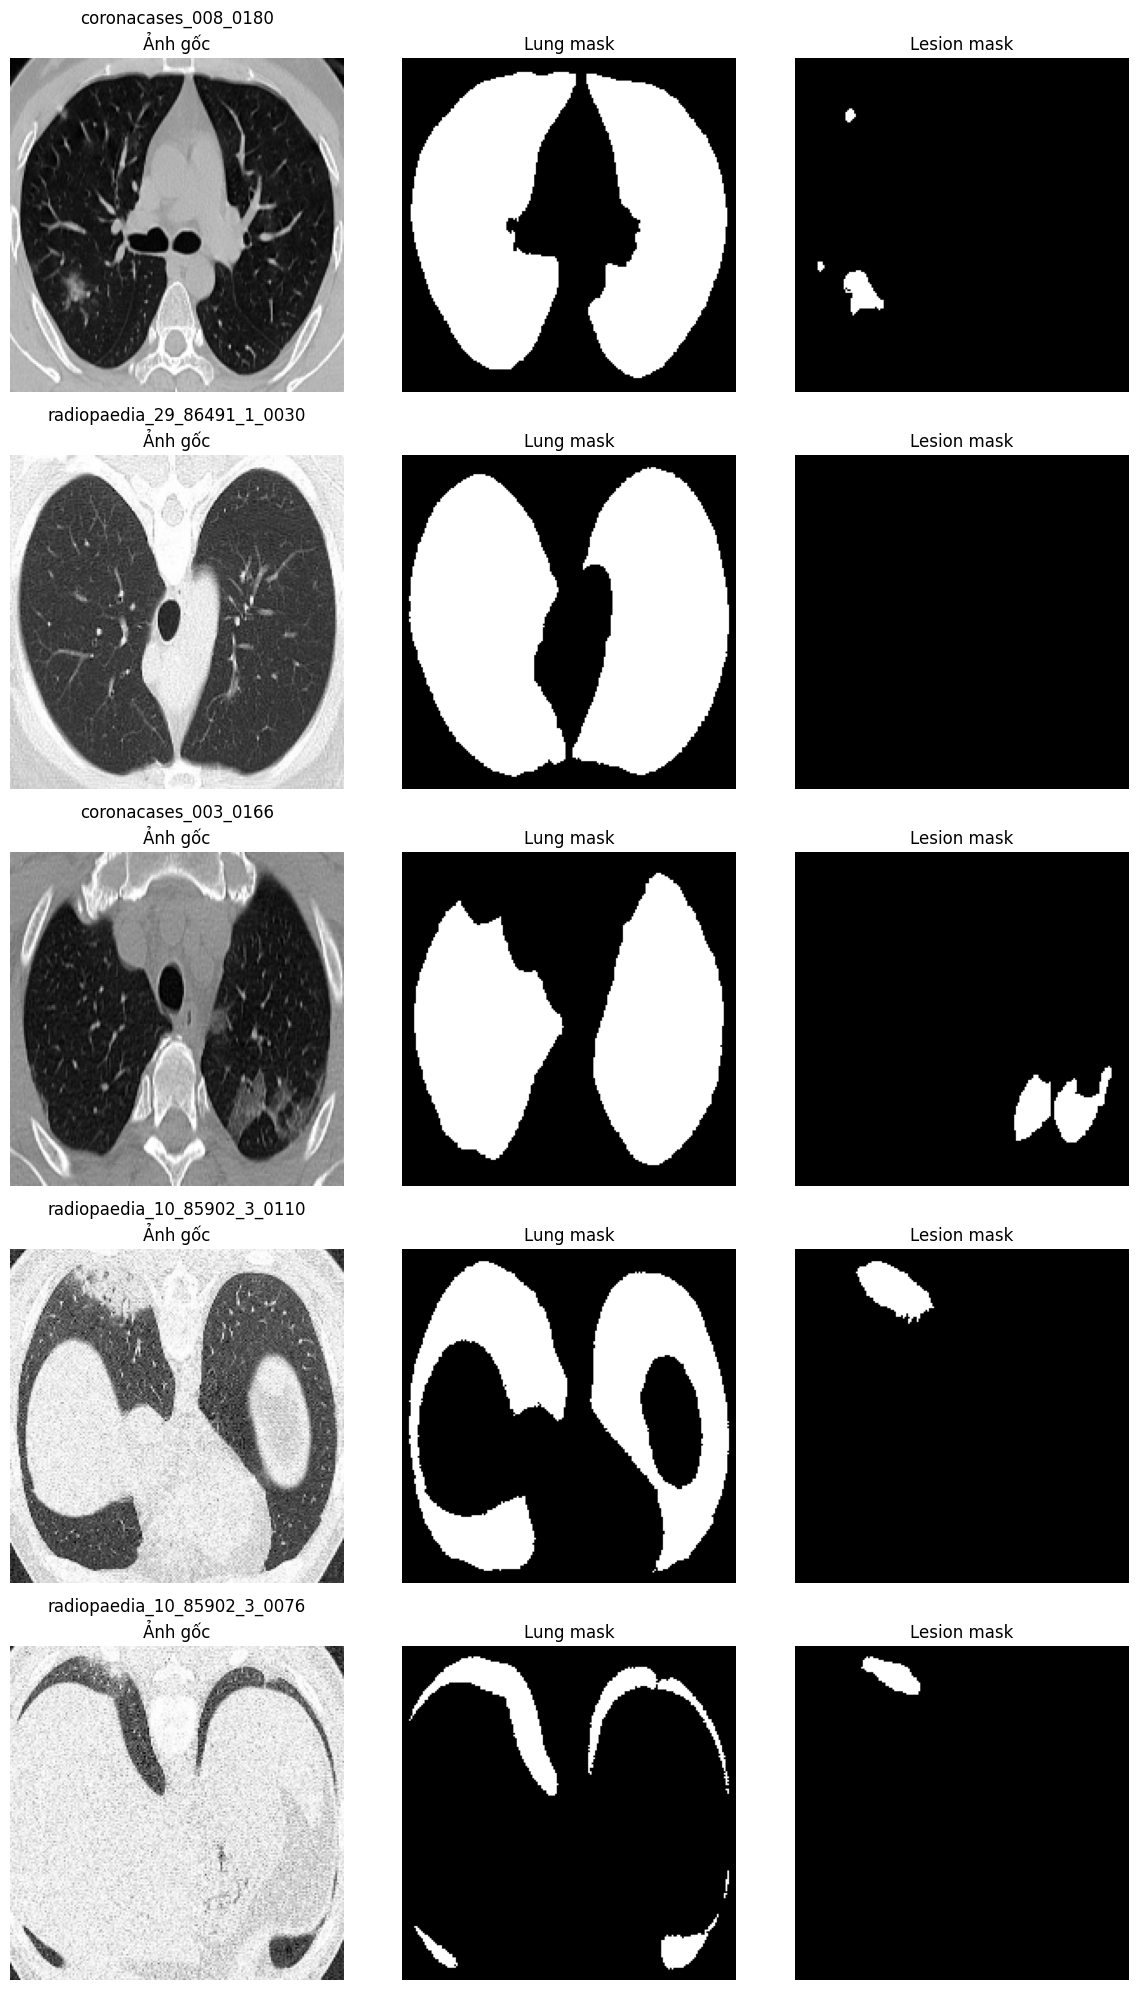

In [10]:
def show_raw_triplets(triplets_list, start_idx=0, n_show=5):
    n = min(n_show, len(triplets_list) - start_idx)
    if n <= 0:
        print("Không có dữ liệu để hiển thị.")
        return

    plt.figure(figsize=(12, 4 * n))

    for i in range(n):
        img_p, lung_p, lesion_p, sid = triplets_list[start_idx + i]

        img_show, lung_show, lesion_show = preprocess_for_display(img_p, lung_p, lesion_p)

        img_show = img_show.numpy()[..., 0]
        lung_show = lung_show.numpy()[..., 0]
        lesion_show = lesion_show.numpy()[..., 0]

        plt.subplot(n, 3, i * 3 + 1)
        plt.title(f"{sid}\nẢnh gốc")
        plt.imshow(img_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.title("Lung mask")
        plt.imshow(lung_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.title("Lesion mask")
        plt.imshow(lesion_show, cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_raw_triplets(train_triplets, start_idx=0, n_show=5)

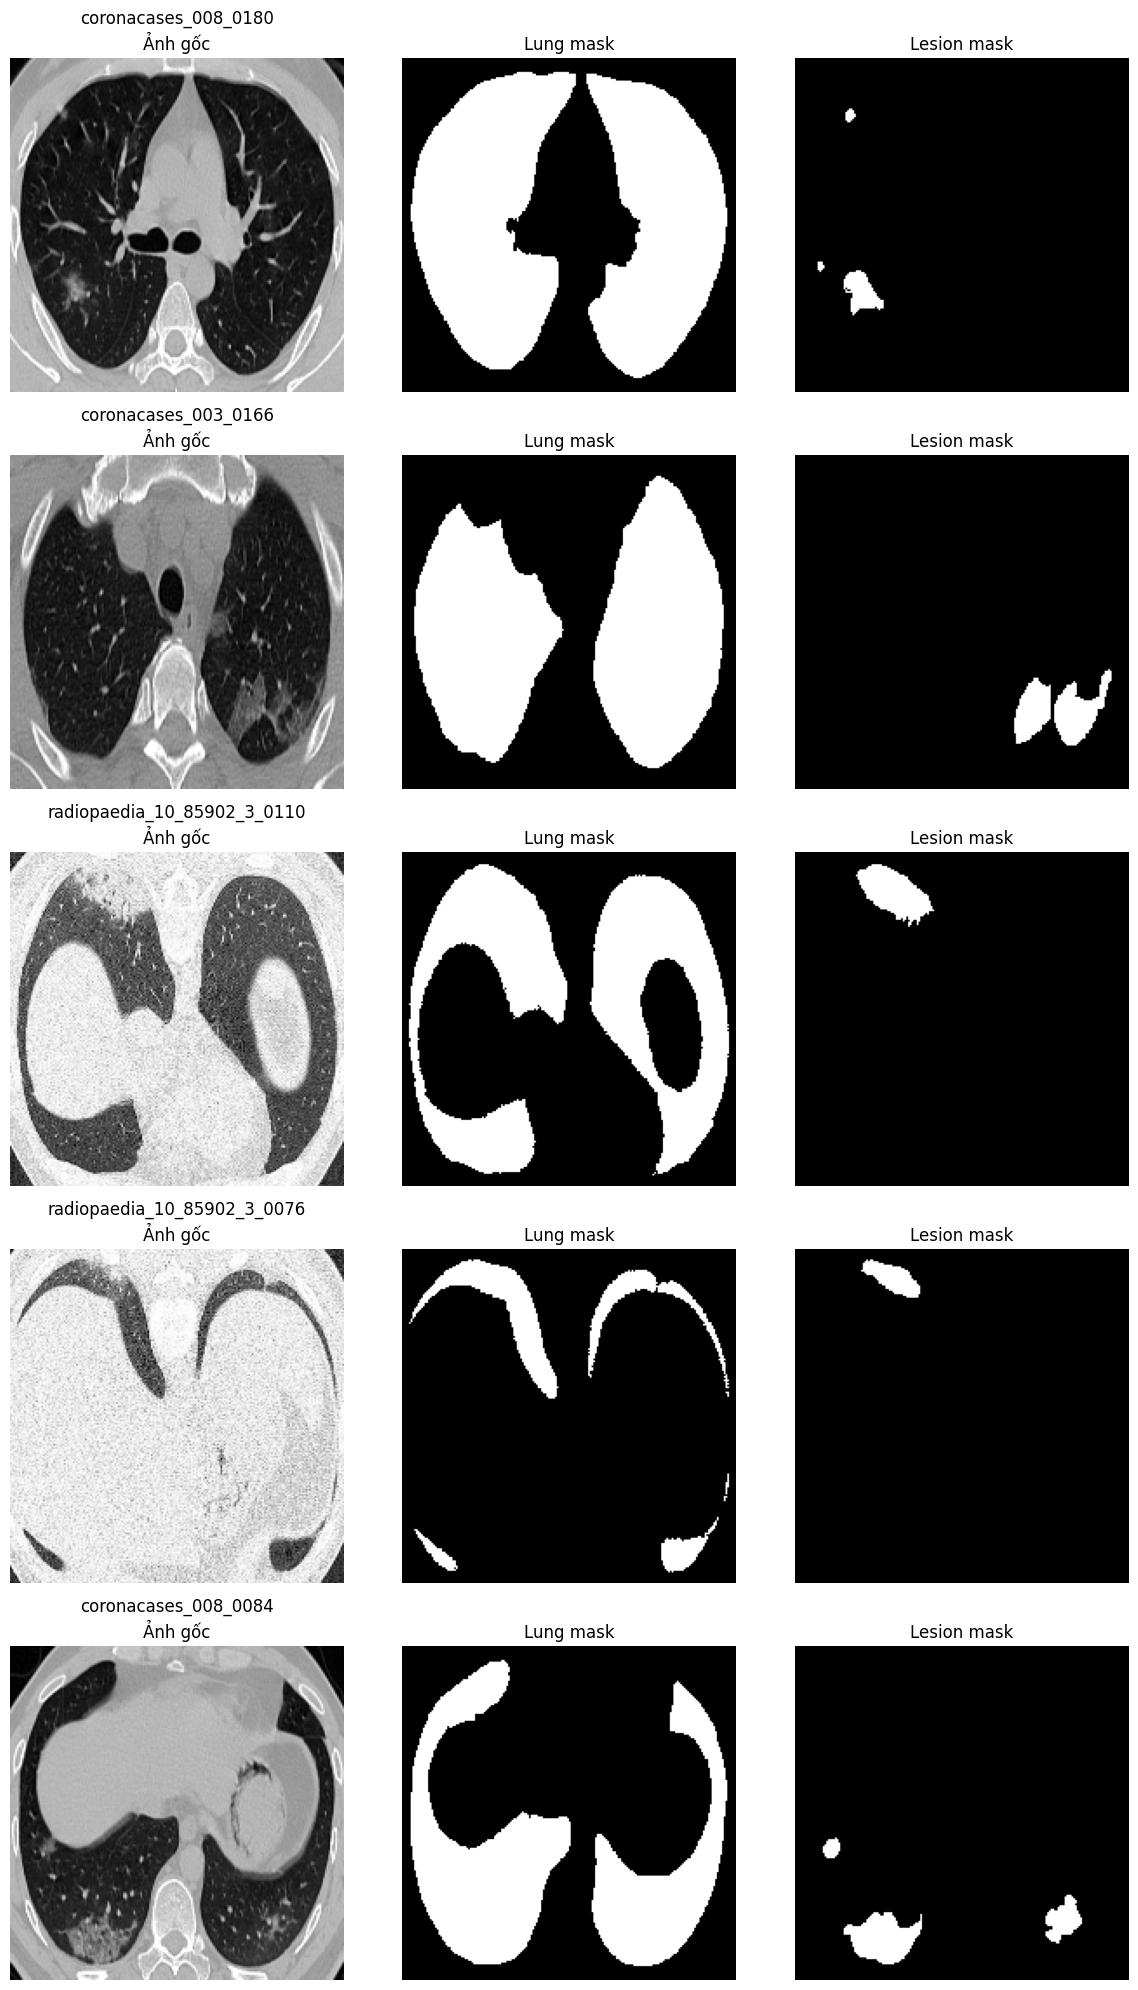

In [11]:
def show_positive_raw_triplets(triplets_list, start_idx=0, n_show=5):
    positive_samples = []

    for img_p, lung_p, lesion_p, sid in triplets_list:
        lesion_raw = _read_tif_cv2(lesion_p)[..., 0]
        if np.any(lesion_raw > 0):
            positive_samples.append((img_p, lung_p, lesion_p, sid))

    if len(positive_samples) == 0:
        print("Không tìm thấy mẫu nào có tổn thương.")
        return

    selected = positive_samples[start_idx:start_idx + n_show]
    n = len(selected)

    if n == 0:
        print("start_idx vượt quá số mẫu có tổn thương.")
        return

    plt.figure(figsize=(12, 4 * n))

    for i, (img_p, lung_p, lesion_p, sid) in enumerate(selected):
        img_show, lung_show, lesion_show = preprocess_for_display(img_p, lung_p, lesion_p)

        img_show = img_show.numpy()[..., 0]
        lung_show = lung_show.numpy()[..., 0]
        lesion_show = lesion_show.numpy()[..., 0]

        plt.subplot(n, 3, i * 3 + 1)
        plt.title(f"{sid}\nẢnh gốc")
        plt.imshow(img_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.title("Lung mask")
        plt.imshow(lung_show, cmap="gray")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.title("Lesion mask")
        plt.imshow(lesion_show, cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_positive_raw_triplets(train_triplets, start_idx=0, n_show=5)

In [12]:
import tensorflow as tf
from tensorflow import keras

tf.keras.backend.clear_session()
keras.mixed_precision.set_global_policy("float32")

print("Global policy:", keras.mixed_precision.global_policy())

Global policy: <DTypePolicy "float32">


## Xây dựng mô hình theo tinh thần bài báo / notebook novel-unet2_build_model
- Giữ nguyên toàn bộ phần tiền xử lý dữ liệu phía trên.
- Phần dưới thay bằng kiến trúc encoder-decoder dùng EfficientNet backbone.
- Decoder sử dụng nested skip pathways kiểu UNet++ để gần với tinh thần “novel U-Net” trong bài báo.
- Đầu ra dùng sigmoid cho bài toán phân vùng nhị phân.
- Có hỗ trợ chọn activation nội bộ để thử nghiệm ReLU, LeakyReLU, ELU hoặc PReLU.


In [13]:
from tensorflow.keras import layers, Model

BACKBONE = "B0"          # chọn B0 để chạy ổn định; có thể đổi sang B3/B7 nếu đủ VRAM
ACTIVATION = "relu"      # relu | leaky_relu | elu | prelu | tanh
FREEZE_ENCODER = False    # True nếu muốn cố định encoder ImageNet ở giai đoạn đầu
USE_IMAGENET = True


def get_backbone(name="B0", input_shape=(IMG_SIZE, IMG_SIZE, 3), weights="imagenet"):
    name = name.upper()
    if name == "B0":
        base = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
    elif name == "B3":
        base = tf.keras.applications.EfficientNetB3(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
    elif name == "B7":
        base = tf.keras.applications.EfficientNetB7(
            include_top=False,
            weights=weights,
            input_shape=input_shape,
        )
    else:
        raise ValueError("BACKBONE phải là B0, B3 hoặc B7")

    skips = [
        base.get_layer("block2a_expand_activation").output,
        base.get_layer("block3a_expand_activation").output,
        base.get_layer("block4a_expand_activation").output,
        base.get_layer("block6a_expand_activation").output,
    ]
    bottleneck = base.output
    return base, base.input, skips, bottleneck


def apply_activation(x, activation="relu", name=None):
    activation = activation.lower()
    if activation == "relu":
        return layers.Activation("relu", name=name)(x)
    if activation == "leaky_relu":
        return layers.LeakyReLU(negative_slope=0.1, name=name)(x)
    if activation == "elu":
        return layers.ELU(alpha=1.0, name=name)(x)
    if activation == "prelu":
        return layers.PReLU(shared_axes=[1, 2], name=name)(x)
    if activation == "tanh":
        return layers.Activation("tanh", name=name)(x)
    raise ValueError("ACTIVATION không hợp lệ")


def conv_block(x, filters, activation="relu", name_prefix="block"):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = apply_activation(x, activation=activation, name=f"{name_prefix}_act1")

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn2")(x)
    x = apply_activation(x, activation=activation, name=f"{name_prefix}_act2")
    return x


def upsample_like(x, ref, name):
    x = layers.UpSampling2D((2, 2), interpolation="bilinear", name=f"{name}_up")(x)
    x = layers.Conv2D(ref.shape[-1] if ref.shape[-1] is not None else 64, 1, padding="same", name=f"{name}_align")(x)
    return x


def build_novel_unet(backbone_name="B0", input_shape=(IMG_SIZE, IMG_SIZE, 3), activation="relu"):
    weights = "imagenet" if USE_IMAGENET else None
    base, inputs, skips, bottleneck = get_backbone(backbone_name, input_shape, weights=weights)
    base.trainable = not FREEZE_ENCODER

    x0_0, x1_0, x2_0, x3_0 = skips
    x4_0 = bottleneck

    # Chuẩn hóa số kênh trước khi đưa vào nested decoder
    f0, f1, f2, f3, f4 = 64, 128, 256, 384, 512
    x0_0 = layers.Conv2D(f0, 1, padding="same", name="proj_x0_0")(x0_0)
    x1_0 = layers.Conv2D(f1, 1, padding="same", name="proj_x1_0")(x1_0)
    x2_0 = layers.Conv2D(f2, 1, padding="same", name="proj_x2_0")(x2_0)
    x3_0 = layers.Conv2D(f3, 1, padding="same", name="proj_x3_0")(x3_0)
    x4_0 = layers.Conv2D(f4, 1, padding="same", name="proj_x4_0")(x4_0)

    # Nested skip pathways kiểu UNet++ / bài báo mô tả dense skip links
    x3_1 = conv_block(layers.Concatenate(name="concat_x3_1")([x3_0, upsample_like(x4_0, x3_0, "x3_1")]), f3, activation, "x3_1")
    x2_1 = conv_block(layers.Concatenate(name="concat_x2_1")([x2_0, upsample_like(x3_0, x2_0, "x2_1")]), f2, activation, "x2_1")
    x1_1 = conv_block(layers.Concatenate(name="concat_x1_1")([x1_0, upsample_like(x2_0, x1_0, "x1_1")]), f1, activation, "x1_1")
    x0_1 = conv_block(layers.Concatenate(name="concat_x0_1")([x0_0, upsample_like(x1_0, x0_0, "x0_1")]), f0, activation, "x0_1")

    x2_2 = conv_block(layers.Concatenate(name="concat_x2_2")([x2_0, x2_1, upsample_like(x3_1, x2_0, "x2_2")]), f2, activation, "x2_2")
    x1_2 = conv_block(layers.Concatenate(name="concat_x1_2")([x1_0, x1_1, upsample_like(x2_1, x1_0, "x1_2")]), f1, activation, "x1_2")
    x0_2 = conv_block(layers.Concatenate(name="concat_x0_2")([x0_0, x0_1, upsample_like(x1_1, x0_0, "x0_2")]), f0, activation, "x0_2")

    x1_3 = conv_block(layers.Concatenate(name="concat_x1_3")([x1_0, x1_1, x1_2, upsample_like(x2_2, x1_0, "x1_3")]), f1, activation, "x1_3")
    x0_3 = conv_block(layers.Concatenate(name="concat_x0_3")([x0_0, x0_1, x0_2, upsample_like(x1_2, x0_0, "x0_3")]), f0, activation, "x0_3")

    x0_4 = conv_block(layers.Concatenate(name="concat_x0_4")([x0_0, x0_1, x0_2, x0_3, upsample_like(x1_3, x0_0, "x0_4")]), f0, activation, "x0_4")

    x = layers.UpSampling2D((2, 2), interpolation="bilinear", name="final_up")(x0_4)
    x = conv_block(x, 32, activation=activation, name_prefix="final_refine")
    outputs = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="mask")(x)

    return Model(inputs, outputs, name=f"NovelUNet_{backbone_name}_{activation}")


model = build_novel_unet(
    backbone_name=BACKBONE,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    activation=ACTIVATION,
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "NovelUNet_B0_relu"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 192, 192,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 192, 192,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 192, 192,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 193, 193,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 96, 96,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 96, 96,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 96, 96,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 96, 96,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 96, 96,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 96, 96,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 96, 96,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 96, 96,    │        512 │ block1a_se_excit

 Total params: 16,159,492 (61.64 MB)

 Trainable params: 16,111,197 (61.46 MB)

 Non-trainable params: 48,295 (188.66 KB)

In [14]:
# Loss và metric theo tinh thần bài báo: Dice + IoU, đầu ra nhị phân với sigmoid.
EPS = 1e-7


def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
    return tf.reduce_mean((2.0 * intersection + EPS) / (denominator + EPS))


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def iou_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3]) - intersection
    return tf.reduce_mean((intersection + EPS) / (union + EPS))


def iou_loss(y_true, y_pred):
    return 1.0 - iou_coef(y_true, y_pred)


def bce_loss(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))


def combo_loss(y_true, y_pred, alpha=0.4, beta=0.4, gamma=0.2):
    return alpha * dice_loss(y_true, y_pred) + beta * iou_loss(y_true, y_pred) + gamma * bce_loss(y_true, y_pred)


def precision_m(y_true, y_pred):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1.0 - y_true) * y_pred)
    return (tp + EPS) / (tp + fp + EPS)


def recall_m(y_true, y_pred):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred)
    fn = tf.reduce_sum(y_true * (1.0 - y_pred))
    return (tp + EPS) / (tp + fn + EPS)


optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=combo_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        dice_coef,
        iou_coef,
        precision_m,
        recall_m,
    ],
)

print("Model name:", model.name)
print("Backbone:", BACKBONE)
print("Activation:", ACTIVATION)
print("Loss: combo_loss = 0.4*Dice + 0.4*IoU + 0.2*BCE")
print("Optimizer: Adam(lr=1e-3)")


Model name: NovelUNet_B0_relu
Backbone: B0
Activation: relu
Loss: combo_loss = 0.4*Dice + 0.4*IoU + 0.2*BCE
Optimizer: Adam(lr=1e-3)


In [15]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "novel_unet_best.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "novel_unet_latest.keras",
        save_best_only=False,
        verbose=0,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
]


In [16]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/20


I0000 00:00:1776445127.946100      71 service.cc:152] XLA service 0x7e3ba02202b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776445127.946150      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776445127.946155      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776445136.308730      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-17 16:59:07.821371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 16:59:07.957617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 16:59:08.742917: E external/local_xl

2949/2949 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - binary_accuracy: 0.9625 - dice_coef: 0.2977 - iou_coef: 0.2271 - loss: 0.6212 - precision_m: 0.4501 - recall_m: 0.8702
Epoch 1: val_dice_coef improved from -inf to 0.16777, saving model to novel_unet_best.keras
2949/2949 ━━━━━━━━━━━━━━━━━━━━ 313s 70ms/step - binary_accuracy: 0.9625 - dice_coef: 0.2977 - iou_coef: 0.2271 - loss: 0.6212 - precision_m: 0.4501 - recall_m: 0.8702 - val_binary_accuracy: 0.9856 - val_dice_coef: 0.1678 - val_iou_coef: 0.1179 - val_loss: 0.7052 - val_precision_m: 0.8975 - val_recall_m: 0.6438 - learning_rate: 0.0010
Epoch 2/20
2949/2949 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - binary_accuracy: 0.9846 - dice_coef: 0.3962 - iou_coef: 0.3272 - loss: 0.5253 - precision_m: 0.6551 - recall_m: 0.8806
Epoch 2: val_dice_coef did not improve from 0.16777
2949/2949 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - binary_accuracy: 0.9846 - dice_coef: 0.3962 - iou_coef: 0.3272 - loss: 0.5253 - precision_m: 0.6551 - recall_m: 0.8806 - val_binary

In [17]:
import json

with open("history.json", "w") as f:
    json.dump(history.history, f)

with open("last_epoch.txt", "w") as f:
    f.write(str(len(history.history["loss"])))


In [18]:
custom_objects = {
    "combo_loss": combo_loss,
    "dice_coef": dice_coef,
    "dice_loss": dice_loss,
    "iou_coef": iou_coef,
    "iou_loss": iou_loss,
    "bce_loss": bce_loss,
    "precision_m": precision_m,
    "recall_m": recall_m,
}

best_model = tf.keras.models.load_model(
    "novel_unet_best.keras",
    custom_objects=custom_objects,
)

print("Loaded best model:", best_model.name)


Loaded best model: NovelUNet_B0_relu


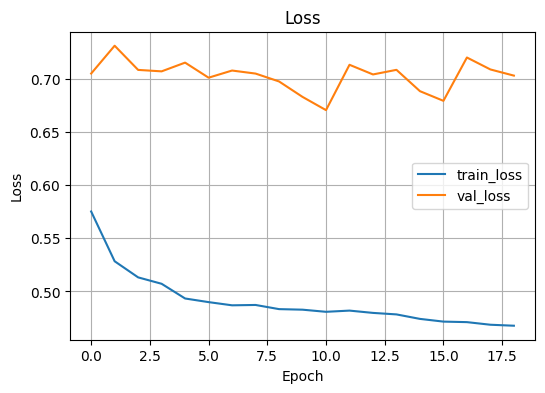

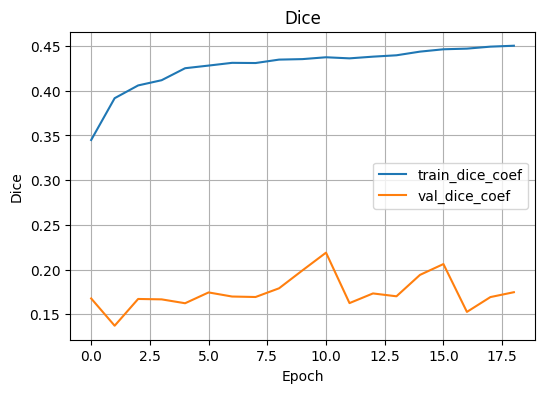

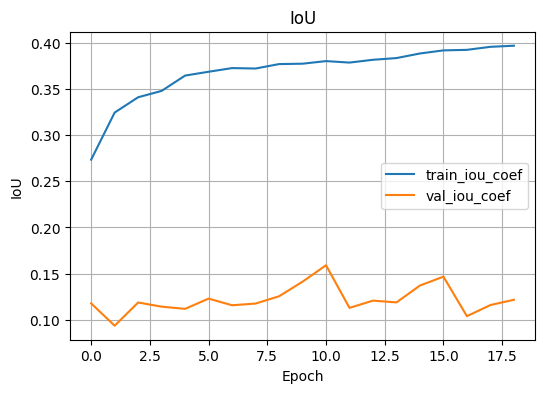

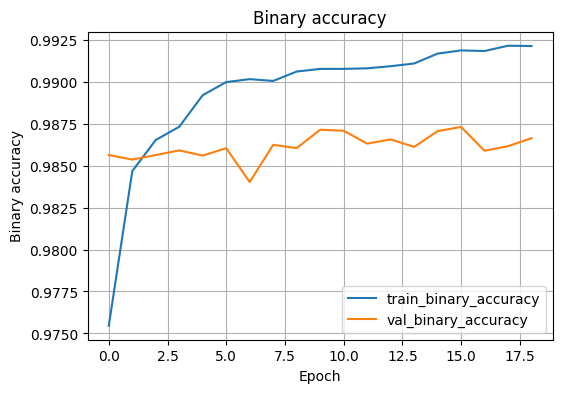

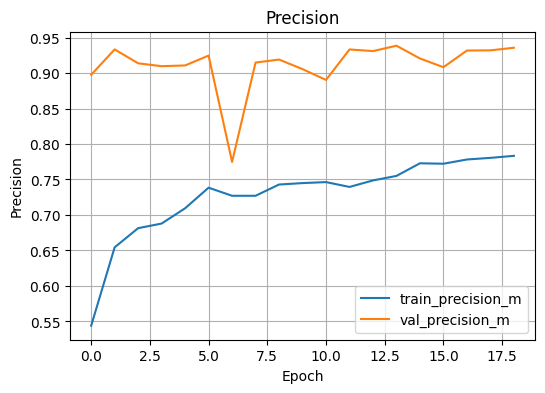

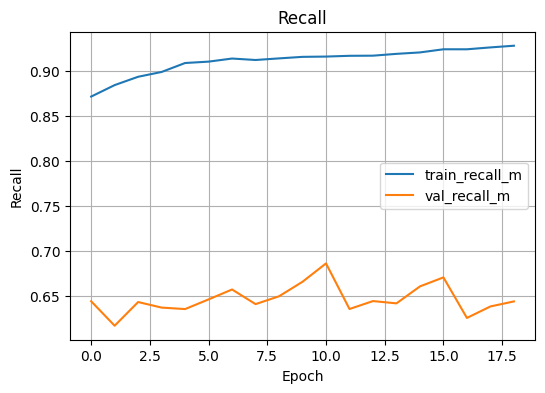

In [19]:
def plot_history_any(hist_or_dict):
    if hist_or_dict is None:
        print("Không có history để vẽ.")
        return

    h = hist_or_dict if isinstance(hist_or_dict, dict) else hist_or_dict.history

    plot_specs = [
        ("loss", "val_loss", "Loss"),
        ("dice_coef", "val_dice_coef", "Dice"),
        ("iou_coef", "val_iou_coef", "IoU"),
        ("binary_accuracy", "val_binary_accuracy", "Binary accuracy"),
        ("precision_m", "val_precision_m", "Precision"),
        ("recall_m", "val_recall_m", "Recall"),
    ]

    for train_key, val_key, ylabel in plot_specs:
        if train_key not in h:
            continue
        plt.figure(figsize=(6, 4))
        plt.plot(h[train_key], label=f"train_{train_key}")
        if val_key in h:
            plt.plot(h[val_key], label=f"val_{train_key}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(ylabel)
        plt.legend()
        plt.grid(True)
        plt.show()

plot_history_any(history)


In [20]:
test_metrics = best_model.evaluate(test_ds, verbose=1)
print("Test metrics:")
for name, value in zip(best_model.metrics_names, test_metrics):
    print(f"- {name}: {value:.6f}")


100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - binary_accuracy: 0.9119 - dice_coef: 0.6875 - iou_coef: 0.5546 - loss: 0.4013 - precision_m: 0.7272 - recall_m: 0.7809
Test metrics:
- loss: 0.451248
- compile_metrics: 0.894503


2026-04-17 18:02:29.495171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 18:02:29.629154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 18:02:32.006859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 18:02:32.153217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 18:02:32.294020: E external/local_xla/xla/stream_

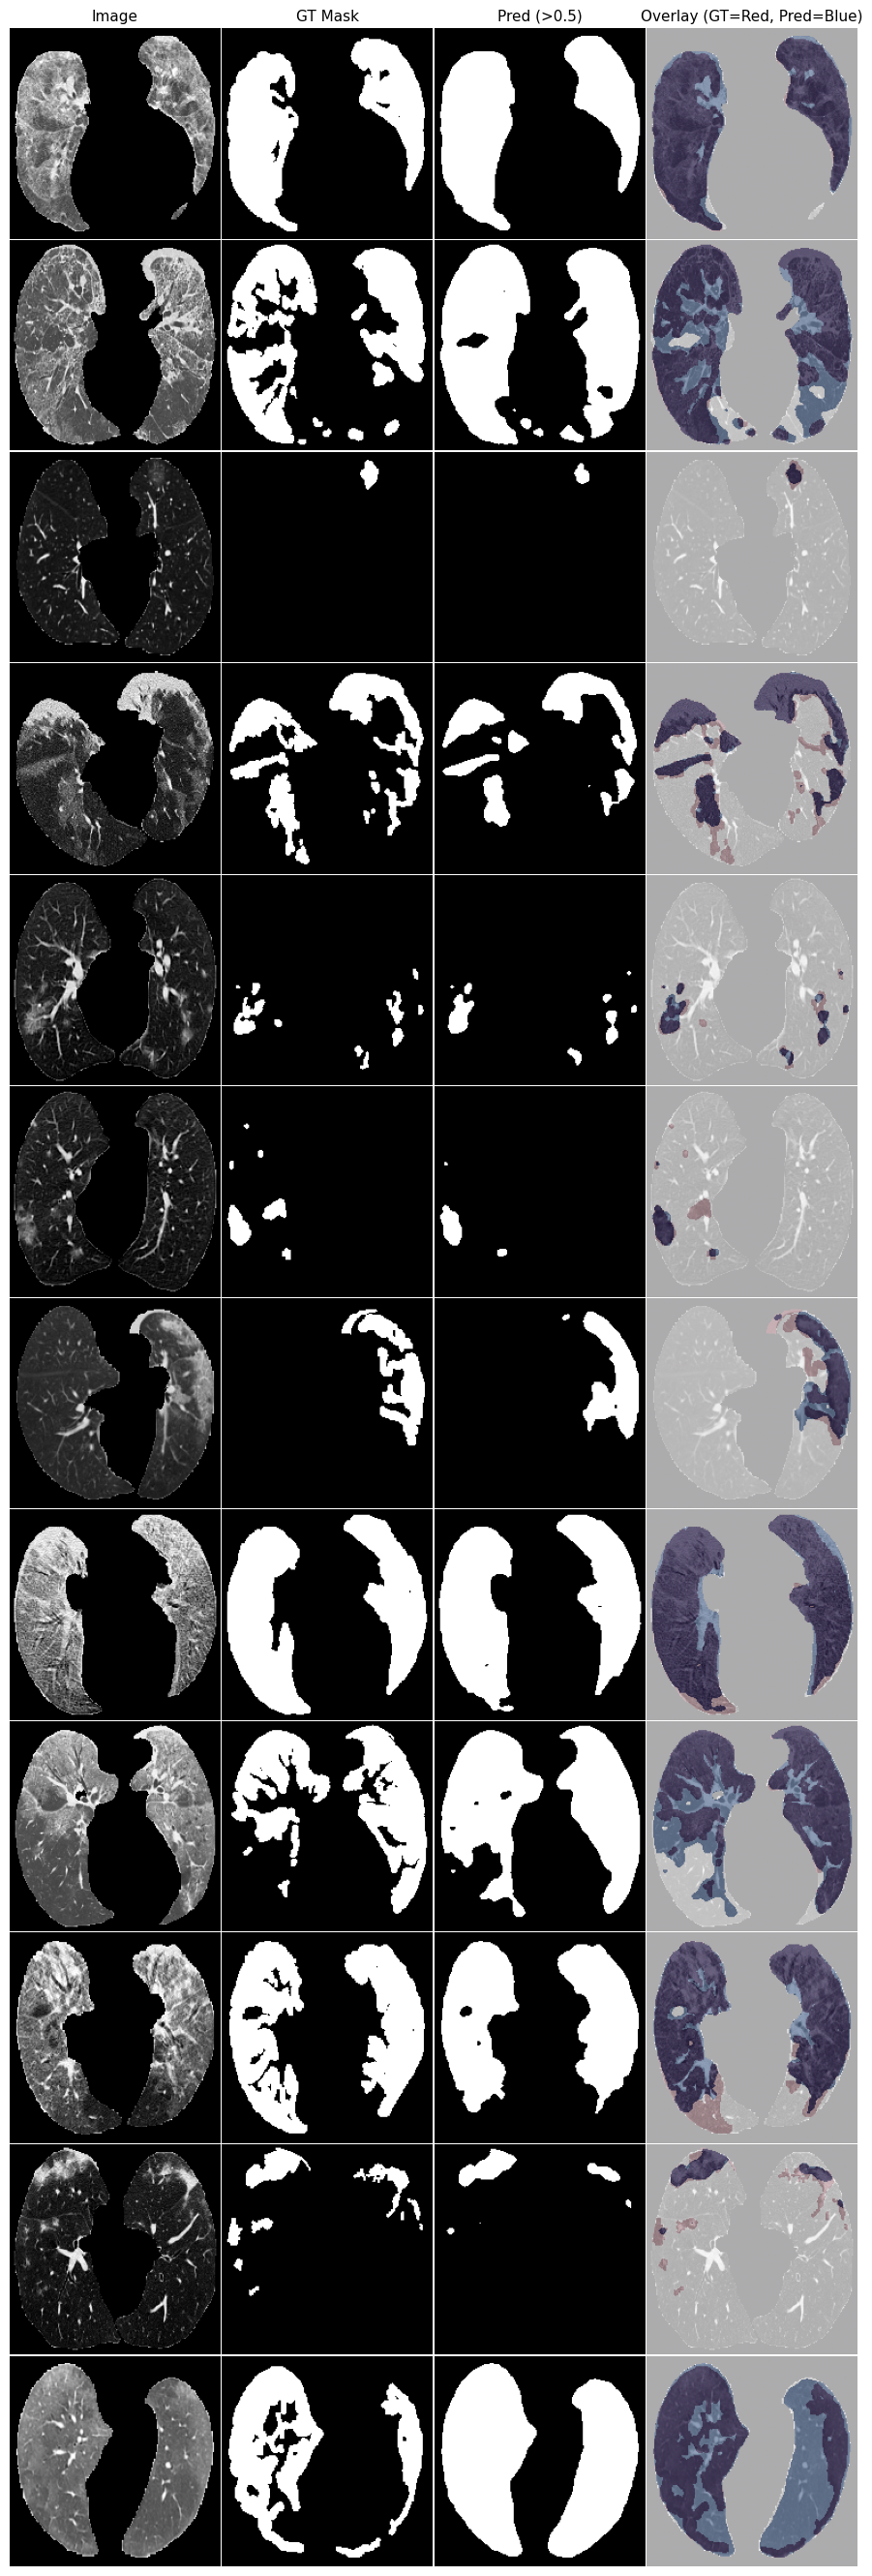

In [21]:
THRESH = 0.5

def visualize_test_square_grid(model, ds, n=12, thresh=0.5, alpha=0.45):
    samples_x = []
    samples_y = []

    for xb, yb in ds:
        x_np = xb.numpy()
        y_np = yb.numpy()

        for i in range(x_np.shape[0]):
            samples_x.append(x_np[i])
            samples_y.append(y_np[i])
            if len(samples_x) >= n:
                break

        if len(samples_x) >= n:
            break

    if len(samples_x) == 0:
        print("Không có dữ liệu để hiển thị.")
        return

    X = np.stack(samples_x, axis=0)
    Y = np.stack(samples_y, axis=0)

    if Y.ndim == 4:
        Y = Y[..., 0]
    else:
        Y = Y.squeeze()

    pred = model.predict(X, verbose=0)
    if pred.ndim == 4:
        pred = pred[..., 0]

    pred_bin = (pred > thresh).astype(np.float32)

    n_show = len(X)
    cell = 2.2
    fig_w = 4 * cell
    fig_h = n_show * cell

    fig, axes = plt.subplots(
        nrows=n_show,
        ncols=4,
        figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": 0.005, "hspace": 0.005}
    )

    if n_show == 1:
        axes = np.expand_dims(axes, axis=0)

    def make_square(ax):
        if hasattr(ax, "set_box_aspect"):
            ax.set_box_aspect(1)
        else:
            ax.set_aspect("equal", adjustable="box")

    for i in range(n_show):
        gray = X[i][..., 0]
        gt   = Y[i]
        pr   = pred_bin[i]

        ax = axes[i, 0]
        ax.imshow(gray, cmap="gray")
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Image", fontsize=11)

        ax = axes[i, 1]
        ax.imshow(gt, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("GT Mask", fontsize=11)

        ax = axes[i, 2]
        ax.imshow(pr, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Pred (>{thresh})", fontsize=11)

        ax = axes[i, 3]
        ax.imshow(gray, cmap="gray")
        ax.imshow(gt, alpha=alpha, cmap="Reds", vmin=0, vmax=1)
        ax.imshow(pr, alpha=alpha, cmap="Blues", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Overlay (GT=Red, Pred=Blue)", fontsize=11)

    plt.subplots_adjust(left=0.002, right=0.998, top=0.995, bottom=0.002)
    plt.show()


visualize_test_square_grid(best_model, test_ds, n=12, thresh=THRESH, alpha=0.45)

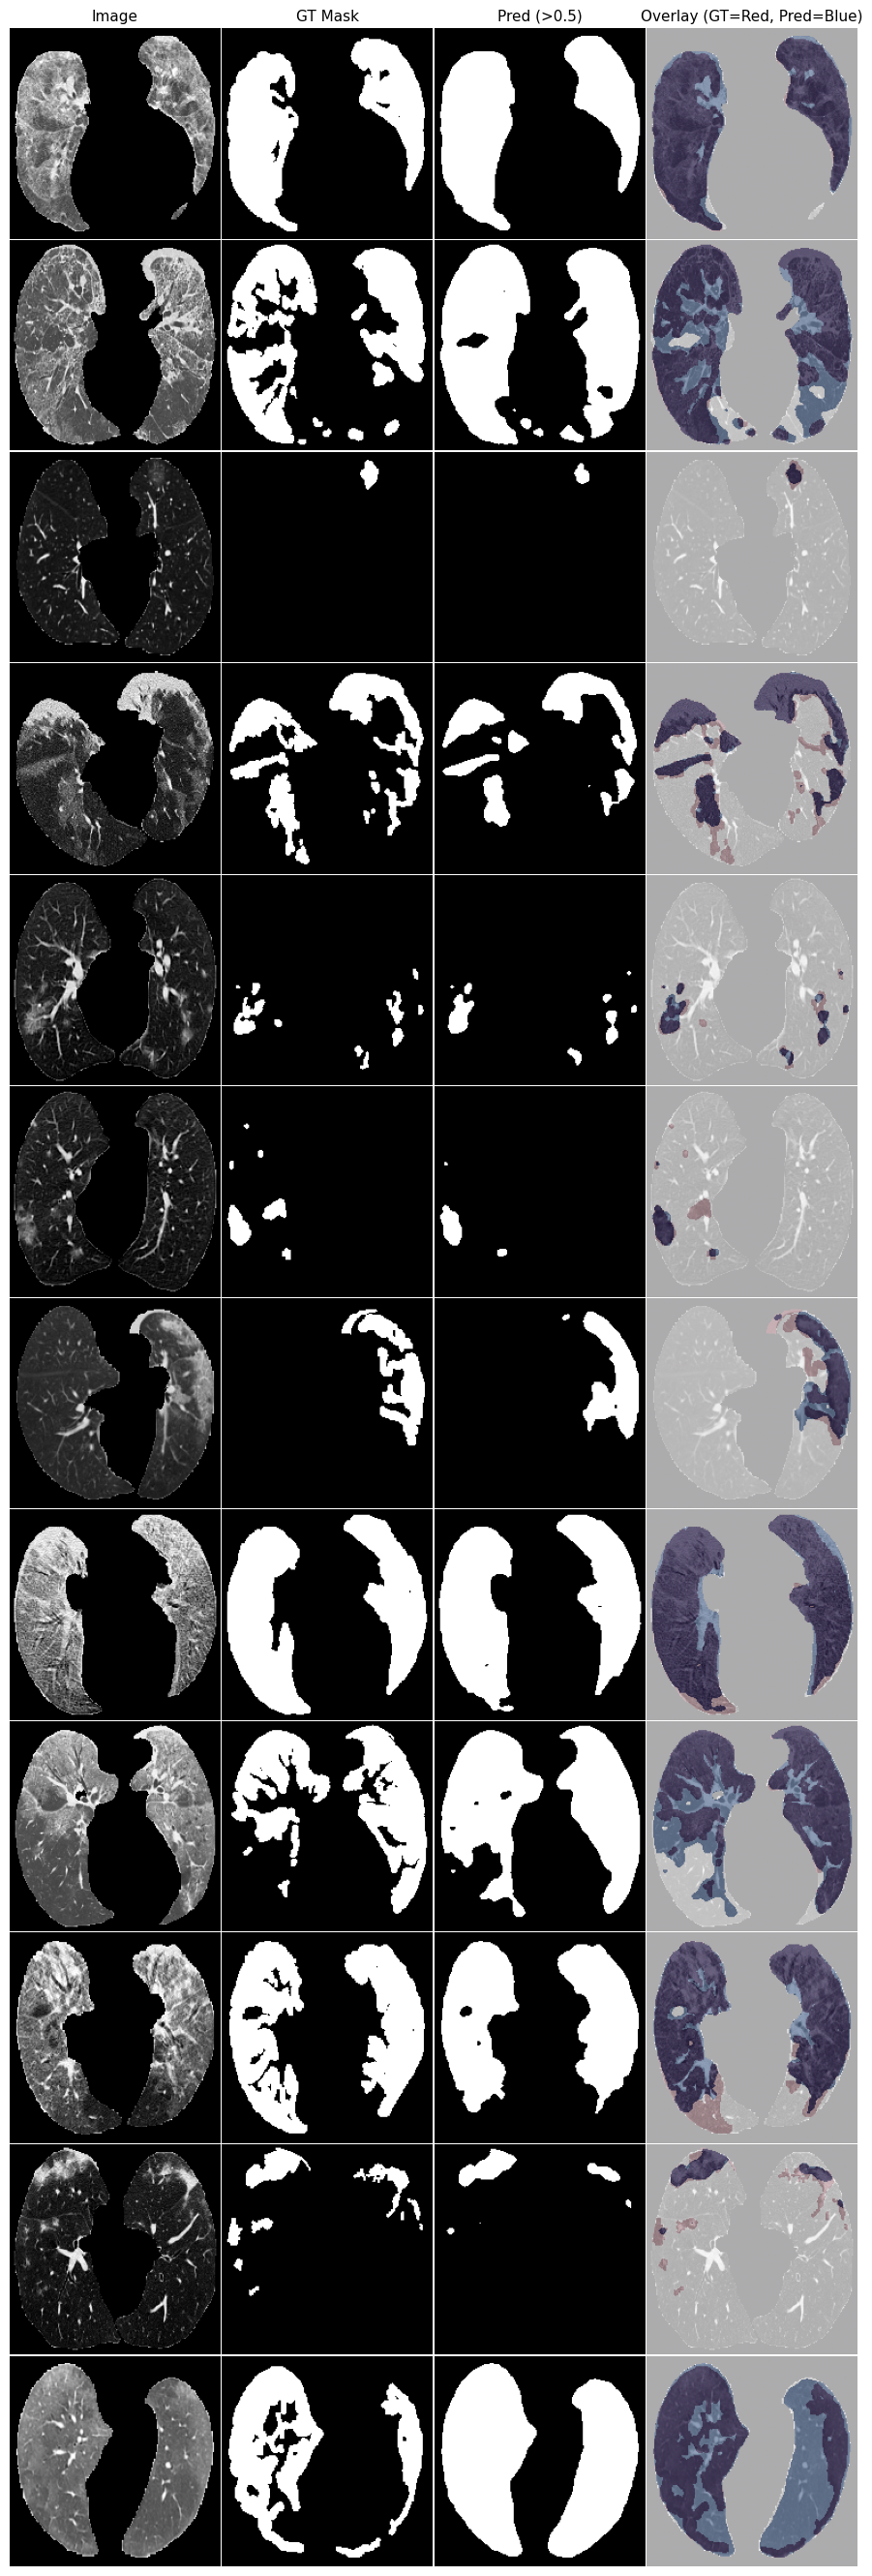

In [22]:
def visualize_positive_test_square_grid(model, ds, n=12, thresh=0.5, alpha=0.45):
    xs, ys = [], []

    for xb, yb in ds:
        x_np = xb.numpy()
        y_np = yb.numpy()

        for i in range(x_np.shape[0]):
            if np.any(y_np[i] > 0):
                xs.append(x_np[i])
                ys.append(y_np[i])

            if len(xs) >= n:
                break

        if len(xs) >= n:
            break

    if len(xs) == 0:
        print("Không tìm thấy mẫu test nào có tổn thương.")
        return

    X = np.stack(xs, axis=0)
    Y = np.stack(ys, axis=0)

    if Y.ndim == 4:
        Y = Y[..., 0]
    else:
        Y = Y.squeeze()

    pred = model.predict(X, verbose=0)
    if pred.ndim == 4:
        pred = pred[..., 0]

    pred_bin = (pred > thresh).astype(np.float32)

    n_show = len(X)
    cell = 2.2
    fig_w = 4 * cell
    fig_h = n_show * cell

    fig, axes = plt.subplots(
        nrows=n_show,
        ncols=4,
        figsize=(fig_w, fig_h),
        gridspec_kw={"wspace": 0.005, "hspace": 0.005}
    )

    if n_show == 1:
        axes = np.expand_dims(axes, axis=0)

    def make_square(ax):
        if hasattr(ax, "set_box_aspect"):
            ax.set_box_aspect(1)
        else:
            ax.set_aspect("equal", adjustable="box")

    for i in range(n_show):
        gray = X[i][..., 0]
        gt   = Y[i]
        pr   = pred_bin[i]

        ax = axes[i, 0]
        ax.imshow(gray, cmap="gray")
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Image", fontsize=11)

        ax = axes[i, 1]
        ax.imshow(gt, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("GT Mask", fontsize=11)

        ax = axes[i, 2]
        ax.imshow(pr, cmap="gray", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Pred (>{thresh})", fontsize=11)

        ax = axes[i, 3]
        ax.imshow(gray, cmap="gray")
        ax.imshow(gt, alpha=alpha, cmap="Reds", vmin=0, vmax=1)
        ax.imshow(pr, alpha=alpha, cmap="Blues", vmin=0, vmax=1)
        make_square(ax)
        ax.axis("off")
        if i == 0:
            ax.set_title("Overlay (GT=Red, Pred=Blue)", fontsize=11)

    plt.subplots_adjust(left=0.002, right=0.998, top=0.995, bottom=0.002)
    plt.show()


visualize_positive_test_square_grid(best_model, test_ds, n=12, thresh=THRESH, alpha=0.45)

In [23]:
SAVE_DIR = "/kaggle/working/prediction_results"
os.makedirs(SAVE_DIR, exist_ok=True)

saved = 0
num_save = 10

for xb, yb in test_ds:
    pb = best_model.predict(xb, verbose=0)
    pb = (pb > THRESH).astype(np.float32)

    x_np = xb.numpy()
    y_np = yb.numpy()

    for i in range(x_np.shape[0]):
        if saved >= num_save:
            break

        img = (x_np[i][..., 0] * 255).astype(np.uint8)
        gt = (y_np[i][..., 0] * 255).astype(np.uint8)
        pred = (pb[i][..., 0] * 255).astype(np.uint8)

        cv2.imwrite(os.path.join(SAVE_DIR, f"{saved:03d}_ct.png"), img)
        cv2.imwrite(os.path.join(SAVE_DIR, f"{saved:03d}_gt.png"), gt)
        cv2.imwrite(os.path.join(SAVE_DIR, f"{saved:03d}_pred.png"), pred)

        saved += 1

    if saved >= num_save:
        break

print("Đã lưu vào:", SAVE_DIR)

Đã lưu vào: /kaggle/working/prediction_results


In [24]:
print("===== SUMMARY =====")
print("Train samples (Dataset3):", len(train_triplets))
print("Val samples   (Dataset3):", len(val_triplets))
print("Test samples  (Dataset1):", len(test_triplets))
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Lung crop:", USE_LUNG_CROP)
print("Lung masking:", USE_LUNG_MASKING)
print("Backbone:", BACKBONE)
print("Activation:", ACTIVATION)
print("Optimizer: Adam(lr=1e-3)")
print("Loss: combo_loss = 0.4*Dice + 0.4*IoU + 0.2*BCE")
print("Model saved:", "novel_unet_best.keras")


===== SUMMARY =====
Train samples (Dataset3): 2949
Val samples   (Dataset3): 571
Test samples  (Dataset1): 100
Image size: 192
Batch size: 1
Lung crop: True
Lung masking: True
Backbone: B0
Activation: relu
Optimizer: Adam(lr=1e-3)
Loss: combo_loss = 0.4*Dice + 0.4*IoU + 0.2*BCE
Model saved: novel_unet_best.keras
